# Provider Daily Economics

This notebook uses the research mart to analyze daily provider token volume and estimated revenue.

Revenue here is an estimate based on observed token activity plus as-of OpenRouter catalog pricing snapshots. It is not audited provider revenue.


In [2]:
from __future__ import annotations

from pathlib import Path
import sys

import pandas as pd

BASE_DIR = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "pyproject.toml").exists())
SRC_DIR = BASE_DIR / "src"
for path in (BASE_DIR, SRC_DIR):
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
print(f"Base dir: {BASE_DIR}")


Base dir: /Users/henrywzh/Desktop/Quant/alternative-data


In [3]:
from research_data.api import build_daily_provider_economics, provider_revenue_daily, provider_tokens_daily

provider_economics = build_daily_provider_economics(base_dir=BASE_DIR, refresh=False)
print("Rows:", len(provider_economics))
provider_economics.head()


Rows: 8659


,usage_date,provider_slug,provider_name,model_permaslug,total_tokens,prompt_tokens,completion_tokens,estimated_revenue,pricing_snapshot_ts,pricing_prompt,pricing_completion,pricing_join_status
0,2026-01-16,anthropic,Anthropic,anthropic/claude-3-5-haiku,1.413208e+09,0.0,0.0,NaN,None,NaN,NaN,missing_snapshot
1,2026-01-16,anthropic,Anthropic,anthropic/claude-3-7-sonnet-20250219,4.092200e+09,0.0,0.0,NaN,None,NaN,NaN,missing_snapshot
2,2026-01-16,anthropic,Anthropic,anthropic/claude-3-7-sonnet-20250219:thinking,2.597868e+08,0.0,0.0,NaN,None,NaN,NaN,missing_snapshot
3,2026-01-16,anthropic,Anthropic,anthropic/claude-3-haiku,2.794971e+08,0.0,0.0,NaN,None,NaN,NaN,missing_snapshot
4,2026-01-16,anthropic,Anthropic,anthropic/claude-3.5-sonnet,7.405579e+08,0.0,0.0,NaN,None,NaN,NaN,missing_snapshot


## Selected Providers


In [4]:
selected_providers = ["openai", "anthropic", "google"]
tokens_daily = provider_tokens_daily(selected_providers, base_dir=BASE_DIR, refresh=False)
revenue_daily = provider_revenue_daily(selected_providers, base_dir=BASE_DIR, refresh=False)

print(tokens_daily.tail(10).to_string(index=False))
print(revenue_daily.tail(10).to_string(index=False))


usage_date provider_slug provider_name                model_permaslug  total_tokens  prompt_tokens  completion_tokens  estimated_revenue  pricing_snapshot_ts  pricing_prompt  pricing_completion pricing_join_status
2026-04-17        google        Google google/gemma-4-31b-it-20260402  2.381094e+09            0.0                0.0                NaN                 None             NaN                 NaN    missing_snapshot
2026-04-17        openai        OpenAI openai/gpt-4.1-mini-2025-04-14  3.692655e+09            0.0                0.0                NaN                 None             NaN                 NaN    missing_snapshot
2026-04-17        openai        OpenAI             openai/gpt-4o-mini  5.692754e+09            0.0                0.0        2134.782741 2026-04-17T08:55:06Z    1.500000e-07        6.000000e-07   matched_avg_price
2026-04-17        openai        OpenAI   openai/gpt-5-mini-2025-08-07  5.626020e+09            0.0                0.0                NaN        

In [5]:
provider_summary = (
    revenue_daily.groupby("provider_slug", as_index=False)
    .agg(
        total_tokens=("total_tokens", "sum"),
        estimated_revenue=("estimated_revenue", "sum"),
        priced_rows=("pricing_join_status", lambda s: int((s.str.startswith("matched")).sum())),
        total_rows=("pricing_join_status", "count"),
    )
    .sort_values("estimated_revenue", ascending=False)
)
provider_summary


,provider_slug,total_tokens,estimated_revenue,priced_rows,total_rows
1,google,3.334580e+13,480371.034970,13,829
2,openai,1.870460e+13,45959.479184,8,828
0,anthropic,2.891563e+13,0.000000,0,828


In [14]:
daily_rollup = (
    revenue_daily.groupby(["usage_date", "provider_slug"], as_index=False)
    .agg(
        total_tokens=("total_tokens", "sum"),
        estimated_revenue=("estimated_revenue", lambda s: s.sum(min_count=1)),
        priced_tokens=("total_tokens", lambda s: s[revenue_daily.loc[s.index, "estimated_revenue"].notna()].sum()),
    )
)
daily_rollup["priced_token_share"] = daily_rollup["priced_tokens"] / daily_rollup["total_tokens"]

daily_rollup


,usage_date,provider_slug,total_tokens,estimated_revenue,priced_tokens,priced_token_share
0,2026-01-16,anthropic,1.784128e+11,NaN,0.000000e+00,0.000000
1,2026-01-16,google,2.952748e+11,NaN,0.000000e+00,0.000000
2,2026-01-16,openai,1.210228e+11,NaN,0.000000e+00,0.000000
3,2026-01-17,anthropic,1.178014e+11,NaN,0.000000e+00,0.000000
4,2026-01-17,google,2.845527e+11,NaN,0.000000e+00,0.000000
...,...,...,...,...,...,...
271,2026-04-16,google,5.642190e+11,227312.479390,2.211653e+11,0.391985
272,2026-04-16,openai,3.418837e+11,21404.116493,1.164944e+11,0.340743
273,2026-04-17,anthropic,8.711767e+10,NaN,0.000000e+00,0.000000
274,2026-04-17,google,7.632503e+10,33180.719814,3.236109e+10,0.423991


<Axes: >

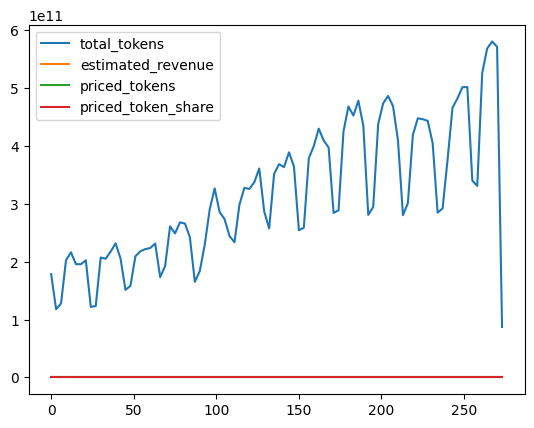

In [19]:
tokens_daily[tokens_daily.provider_slug == 'anthropic']

,usage_date,provider_slug,provider_name,model_permaslug,total_tokens,prompt_tokens,completion_tokens,estimated_revenue,pricing_snapshot_ts,pricing_prompt,pricing_completion,pricing_join_status
0,2026-01-16,anthropic,Anthropic,anthropic/claude-3-5-haiku,1.413208e+09,0.0,0.0,NaN,None,NaN,NaN,missing_snapshot
1,2026-01-16,anthropic,Anthropic,anthropic/claude-3-7-sonnet-20250219,4.092200e+09,0.0,0.0,NaN,None,NaN,NaN,missing_snapshot
2,2026-01-16,anthropic,Anthropic,anthropic/claude-3-7-sonnet-20250219:thinking,2.597868e+08,0.0,0.0,NaN,None,NaN,NaN,missing_snapshot
3,2026-01-16,anthropic,Anthropic,anthropic/claude-3-haiku,2.794971e+08,0.0,0.0,NaN,None,NaN,NaN,missing_snapshot
4,2026-01-16,anthropic,Anthropic,anthropic/claude-3.5-sonnet,7.405579e+08,0.0,0.0,NaN,None,NaN,NaN,missing_snapshot
...,...,...,...,...,...,...,...,...,...,...,...,...
2462,2026-04-17,anthropic,Anthropic,anthropic/claude-4.5-sonnet-20250929,7.322678e+09,0.0,0.0,NaN,None,NaN,NaN,missing_snapshot
2463,2026-04-17,anthropic,Anthropic,anthropic/claude-4.6-opus-20260205,2.355945e+10,0.0,0.0,NaN,None,NaN,NaN,missing_snapshot
2464,2026-04-17,anthropic,Anthropic,anthropic/claude-4.6-opus-fast-20260407,3.225168e+08,0.0,0.0,NaN,None,NaN,NaN,missing_snapshot
2465,2026-04-17,anthropic,Anthropic,anthropic/claude-4.6-sonnet-20260217,3.133246e+10,0.0,0.0,NaN,None,NaN,NaN,missing_snapshot
